In [110]:
import numpy as np

from dataHandler import Config, MetadataHandler, OligosHandler, FeatureManager
from survival_helpers import *
from plots_helpers import *

from matplotlib.colors import LinearSegmentedColormap
import pickle
from joblib import load
from tabulate import tabulate
import math
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


## Load Data

In [111]:
newCmap = LinearSegmentedColormap.from_list("",  ['#CD8500', '#40E0D0'])  # nonORR-ORR['#E78AC3', '#8DA0CB'])  # Controls - HCC ['#CD8500', '#40E0D0']) nonDCR -DCR ['#FFD92F','#E5C494'])
#config_file = "/home/creyna/Vogl-lab_Projects_git/HCC/Metadata/config_survival_trainTest.yaml"
config_file = "/home/creyna/Vogl-lab_Projects_git/HCC/Metadata/config_survival_trainTest.yaml"
config = Config(config_file)
metadata_handler = MetadataHandler(config)
#oligos_handler = OligosHandler(config)
oligos_handler = OligosHandler(config) #, data_type=config.data_types[0])
feature_manager = FeatureManager(config, metadata_handler, oligos_handler,
                                 subgroup = 'all',
                                 with_oligos=True,
                                 with_additional_features = True,
                                 filter_by_entropy=False,
                                 prevalence_threshold_min=0,
                                 prevalence_threshold_max=100)
X_train, y_event_train = feature_manager.get_features_target()
y_time_train = X_train["OS months"]
X_train.drop(columns = ["OS months"], inplace = True)
y_time_train = y_time_train.where(y_event_train == 1, -y_time_train) #np.where(y_event, y_time, -y_time)
#X_train = X_train.loc[:, X_train.apply(lambda col: col.nunique() > 1)]
X_train.shape

(73, 8011)

In [157]:
oligos_handler.get_oligos_metadata_df().loc[oligos_handler.get_oligos_metadata_df().index.str.startswith("twist")]

,pos,len_seq,full name,is_IEDB_or_cntrl,is_pos_cntrl,is_neg_cntrl,is_rand_cntrl,is_IEDB,is_auto,is_infect,...,signalp6_slow,is_topgraph_new,is_topgraph_new_&_old,diamond_mmseqs_intersec_toxin,Organism_complete_name,is_ALIGENT,is_phage,is_allergens,is_influenza,is_TWIST
twist_0,0,0.0,FLAG-tag control,True,False,False,False,NaN,NaN,False,...,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,True
twist_1,306,786.0,allergen_name False allergome_name Hom s Elast...,False,False,False,False,NaN,NaN,False,...,NaN,NaN,NaN,NaN,NaN,NaN,False,True,False,True
twist_10,316,518.0,allergen_name False allergome_name Dro m 7 (10...,False,False,False,False,NaN,NaN,False,...,NaN,NaN,NaN,NaN,NaN,NaN,False,True,False,True
twist_100,102,273.0,allergen_name False allergome_name Tri a 1 (5/...,False,False,False,False,NaN,NaN,False,...,NaN,NaN,NaN,NaN,NaN,NaN,False,True,False,True
twist_1000,0,92.0,allergen_name Sin a 3 (1/1) (1/1) allergome_na...,False,False,False,False,NaN,NaN,False,...,NaN,NaN,NaN,NaN,NaN,NaN,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
twist_99995,68,199.0,YP_001469588.1 hypothetical protein phi1p245 [...,False,False,False,False,NaN,NaN,False,...,NaN,NaN,NaN,NaN,NaN,NaN,True,False,False,True
twist_99996,0,53.0,ACZ63856.1 conserved hypothetical protein [Ent...,False,False,False,False,NaN,NaN,False,...,NaN,NaN,NaN,NaN,NaN,NaN,True,False,False,True
twist_99997,102,234.0,YP_009320848.1 D2 protein [Salmonella phage 10...,False,False,False,False,NaN,NaN,False,...,NaN,NaN,NaN,NaN,NaN,NaN,True,False,False,True
twist_99998,0,190.0,YP_009043388.1 hypothetical protein [Listeria ...,False,False,False,False,NaN,NaN,False,...,NaN,NaN,NaN,NaN,NaN,NaN,True,False,False,True


In [112]:
model_ids = [62, 79, 36, 32, 20, 42, 45, 64, 1, 17]
# Prepare an empty list to collect each model's metrics
time_dependent_auc_train = pd.DataFrame(None, columns=range(1, 25), index=model_ids)
time_dependent_auc_train_full = pd.DataFrame(None, columns=range(1, 25), index=model_ids)
mean_auc_train_full = pd.Series(None, index=model_ids)

time_dependent_auc_antigen_train = pd.DataFrame(None, columns=range(1, 25), index=model_ids)
mean_auc_antigen_train = pd.Series(None, index=model_ids)
time_dependent_auc_antigen_train_full = pd.DataFrame(None, columns=range(1, 25), index=model_ids)
mean_auc_antigen_train_full = pd.Series(None, index=model_ids)

risk_scores_train = pd.DataFrame(None, columns=model_ids, index=X_train.index)
train_shap_values =  pd.DataFrame(0.0, index=X_train.index, columns=X_train.columns)

c_index_train = pd.Series(None, index=model_ids)
c_index_train_ipcw = pd.Series(None, index=model_ids)
c_index_train_censoring = pd.Series(None, index=model_ids)
time_points =  np.arange(1, 25, step=1)

file_path_template = "/home/creyna/Vogl-lab_Projects_git/HCC/results_nestedCV/Renested_cv_results_bestmodel_auc_{}.joblib"
#file_path_template = "/home/creyna/Vogl-lab_Projects_git/HCC/results_foC_nestedCV_filteronTrainingIT/foC_nested_cv_results_bestmodel_auc_{}.joblib"
for model_id in model_ids:
    # Construct the file path for the model results based on its ID/seed.
    # Adjust the path and filename format as needed.
    file_path = file_path_template.format(model_id)
    #file_path = f"/home/creyna/Vogl-lab_Projects_git/HCC/results_nestedCV_ControlsTraining/nested_cv_results_bestmodel_auc_{model_id}.joblib"
    results = load(file_path)

    # Get risk scores from the results (assuming they're stored as 'risk_scores_train')
    train_shap_values += results['train_shap_values']
    risk_scores_train.loc[:, model_id] = results['risk_scores_train']
    time_dependent_auc_train.loc[model_id] = results['time_dependent_auc_train'].mean(skipna=True)

    auc_values_train, mean_auc_train = calculate_cumulative_dynamic_auc(y_time_train, y_time_train,
                                                                        risk_scores_train.loc[:, model_id], time_points)
    time_dependent_auc_train_full.loc[model_id] = auc_values_train
    mean_auc_train_full.loc[model_id] = mean_auc_train

    c_index_train.loc[model_id] = np.mean(results['c_index_train'])
    c_index_train_ipcw.loc[model_id] = c_index_scorer_ipcw(y_time_train, y_time_train, risk_scores_train.loc[:, model_id].values)
    c_index_train_censoring.loc[model_id] = c_index_scorer(y_time_train, risk_scores_train.loc[:, model_id].values)

train_shap_values /= len(model_ids)
top_peptides_train = train_shap_values.abs().mean(0).sort_values(ascending=False).head(15).index
with open('top_peptides_repeats.pkl', 'wb') as file:
    pickle.dump(top_peptides_train, file)


antigen_scores_time_event_train_df = pd.DataFrame(None, columns=model_ids, index=X_train.index)
shap_scaler_train_rep = pd.Series(dtype='object', index=model_ids)
antigen_scaler_train_rep = pd.Series(dtype='object', index=model_ids)
for model_id in model_ids:
    file_path = file_path_template.format(model_id)
    #file_path = f"/home/creyna/Vogl-lab_Projects_git/HCC/results_nestedCV_ControlsTraining/nested_cv_results_bestmodel_auc_{model_id}.joblib"
    results = load(file_path)
    antigen_scores_time_event_train_rep, antigen_threshold_train_rep, shap_scaler_train_rep.loc[model_id], antigen_scaler_train_rep.loc[model_id] = calculate_antigen_scores_scaled(
        results['train_shap_values'],
        y_time_train.abs(), y_event_train,
        top_peptides_train, return_all = True)

    auc_antigen_values_train, mean_auc_antigen = calculate_cumulative_dynamic_auc(y_time_train, y_time_train,
                                                                      antigen_scores_time_event_train_rep['Antigen Score (Scaled)'], time_points)

    time_dependent_auc_antigen_train_full.loc[model_id] = auc_antigen_values_train
    mean_auc_antigen_train_full.loc[model_id] = mean_auc_antigen

    time_dependent_auc_antigen_train_fold = pd.DataFrame(index=np.arange(10), columns=time_points)
    mean_auc_antigen_train_fold = pd.Series(index=np.arange(10))
    i=0
    for valid_idx in results['validation_indices_train']:
        y_valid_fold = y_time_train.iloc[valid_idx]
        auc_values_fold, mean_auc_values_fold = calculate_cumulative_dynamic_auc(y_time_train.loc[y_time_train.index.difference(y_valid_fold.index)] , y_valid_fold,
                                                           antigen_scores_time_event_train_rep.iloc[valid_idx,]['Antigen Score (Scaled)'], time_points)
        time_dependent_auc_antigen_train_fold.loc[i, auc_values_fold.index] = auc_values_fold.values
        mean_auc_antigen_train_fold.loc[i] = mean_auc_values_fold
        i=i+1
    time_dependent_auc_antigen_train.loc[model_id] = time_dependent_auc_antigen_train_fold.mean(skipna=True)
    mean_auc_antigen_train.loc[model_id] = mean_auc_antigen_train_fold.mean(skipna=True)

    antigen_scores_time_event_train_df.loc[:, model_id] = antigen_scores_time_event_train_rep['Antigen Score (Scaled)']
    # Save shap_scaler_train
with open("shap_scaler_train_rep.pkl", "wb") as f:
    pickle.dump(shap_scaler_train_rep, f)
# Save antigen_scaler_train
with open("antigen_scaler_train_rep.pkl", "wb") as f:
    pickle.dump(antigen_scaler_train_rep, f)


merged_df = pd.merge(y_time_train, y_event_train, left_index=True, right_index=True)
merged_df.merge(antigen_scores_time_event_train_df, left_index=True, right_index=True).to_csv("Data/antigen_scores_time_event_train_df.csv", index=True)
merged_df.merge(risk_scores_train, left_index=True, right_index=True).to_csv("Data/risk_scores_time_event_train_df.csv", index=True)

In [146]:
merged_df.merge(risk_scores_train, left_index=True, right_index=True)

,OS months,OS Status,62,79,36,32,20,42,45,64,1,17
SampleName,,,,,,,,,,,,
R14P01_02_LB_004_02_HCC_MUW_A_T_C2,-38.001315,0,0.812223,0.056772,2.06702,1.695877,3.708957,0.048371,0.004606,0.276975,0.028591,0.744392
R14P01_05_LB_009_01_HCC_MUW_A_T_C2,-45.627876,0,0.13243,1.416823,0.176844,0.888364,1.150623,0.918497,0.343029,1.754973,1.454423,1.750046
R14P01_06_LB_026_01_HCC_MUW_A_T_C2,-2.958580,0,0.084135,0.015969,0.162667,0.264095,0.871412,0.765821,0.04594,0.351363,0.288548,0.085106
R14P01_08_HCCAB_24_02_HCC_MUW_A_T_C2,-11.308350,0,0.988745,1.510815,0.601036,0.321885,0.248468,0.401282,1.653222,0.00452,1.692998,0.34318
R14P01_09_HCCAB_27_01_HCC_MUW_A_T_C2,-25.608153,0,0.931506,0.116822,0.00674,0.034967,0.435004,0.045769,0.047399,0.51143,0.010819,0.072759
...,...,...,...,...,...,...,...,...,...,...,...,...
R14P01_68_HCC629_HCC_MUW_A_T_C2,9.960552,1,1.095831,0.086715,0.046205,1.255826,0.155319,0.140339,3.357042,1.086954,0.612508,0.181655
R14P01_70_HCC635_HCC_MUW_A_T_C2,2.859961,1,0.369028,0.068692,8.246492,0.503398,1.749161,0.547445,0.128991,1.626691,1.186302,1.713478
R14P01_71_HCC681_HCC_MUW_A_T_C2,1.347798,1,1.233589,851.587524,1.027439,5142.441895,3.756122,10.776522,39.458363,14.819146,7.40197,340.190063


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
/home/creyna/miniconda3/envs/ML_env/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/creyna/miniconda3/envs/ML_env/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plot

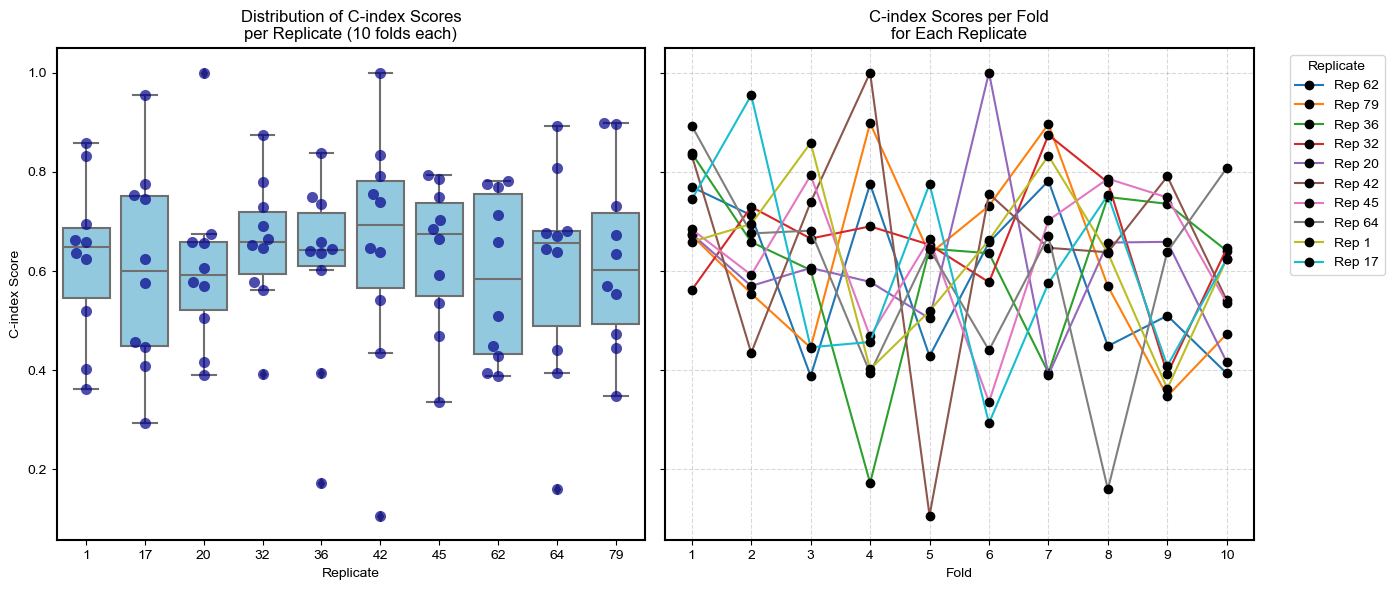

In [114]:
# Initialize lists to store the data for all replicates.
replicate_ids = []  # To store replicate identifier (could be model_id)
folds = []          # To store fold numbers (1 through 10)
c_indices = []      # To store the c-index values

# Assume model_ids is a list of replicate IDs and file_path_template is defined.
for model_id in model_ids:
    file_path = file_path_template.format(model_id)
    results = load(file_path)
    # Assuming results['c_index_train'] is a list/array of 10 c-index values.
    c_index = results['c_index_train']

    # For each fold, store the replicate id, fold number, and c-index value.
    for i, score in enumerate(c_index, start=1):
        replicate_ids.append(model_id)
        folds.append(i)
        c_indices.append(score)

# Create a DataFrame combining all the replicates
df = pd.DataFrame({
    'Replicate': replicate_ids,
    'Fold': folds,
    'C_index': c_indices
})
df['Fold'] = pd.to_numeric(df['Fold'])

# --- Plotting ---

# Create a figure with 2 subplots sharing the y-axis.
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(14, 6), sharey=True)

# Left subplot: Boxplot with overlaid swarm plot showing the c-index distribution for each replicate.
sns.boxplot(x='Replicate', y='C_index', data=df, color='skyblue', ax=ax1)
sns.swarmplot(x='Replicate', y='C_index', data=df, color='darkblue', alpha=0.7, size=8, ax=ax1)
ax1.set_title('Distribution of C-index Scores\nper Replicate (10 folds each)', fontsize=12)
ax1.set_xlabel('Replicate', fontsize=10)
ax1.set_ylabel('C-index Score', fontsize=10)

# Right subplot: Line/scatter plot showing c-index scores per fold for each replicate.
# Plot one line per replicate.
for rep in df['Replicate'].unique():
    rep_data = df[df['Replicate'] == rep].sort_values(by='Fold')
    ax2.plot(rep_data['Fold'], rep_data['C_index'], marker='o', linestyle='-',
             label=f"Rep {rep}", markerfacecolor="black", markeredgecolor="black")

ax2.set_xlabel('Fold', fontsize=10)
ax2.set_title('C-index Scores per Fold\nfor Each Replicate', fontsize=12)
ax2.set_xticks(np.arange(1, 11))
# Adjust y-limits based on the data.
ax2.set_ylim(df['C_index'].min() - 0.05, df['C_index'].max() + 0.05)
ax2.grid(True, linestyle='--', alpha=0.15, color="black")
ax2.legend(title="Replicate", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
#plt.savefig(f'{config.figures_dir}/C-index_scores_all_replicates.png', dpi=300, bbox_inches='tight')

In [115]:
number_peptides = f"{X_train.shape[1]}"

## SHAP values

<Axes: >

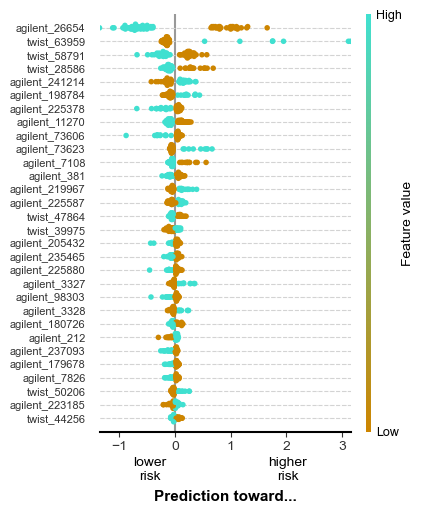

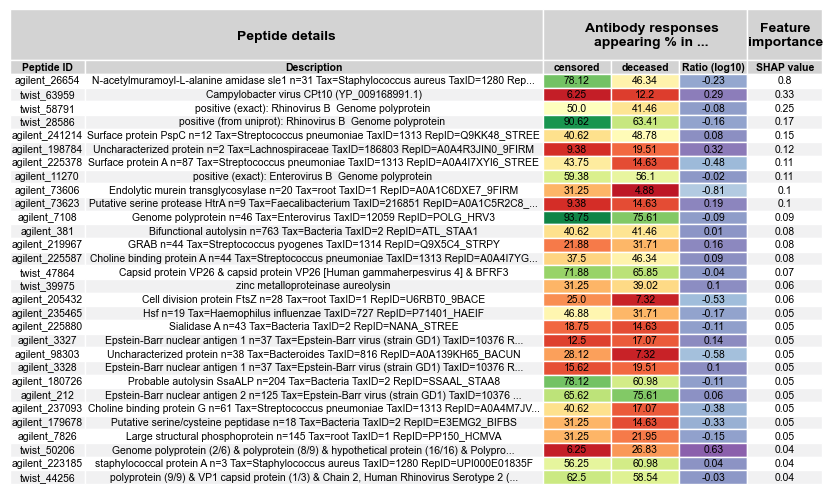

In [116]:
plot_shap_values(train_shap_values.values, X_train, cmap=newCmap, max_display=30,
                 label_groups = ['lower\nrisk', 'higher\nrisk'], suffix_file=f'xgb_Cox-Hazard_trainingSet_{number_peptides}',
                 save_fig = True,  figures_dir = config.figures_dir )

oligos_metadata = oligos_handler.get_oligos_metadata_df()[['Description', 'full name', 'len_seq', 'pos', 'Organism_complete_name']]
y_event_train.name = config.col_target  # Naming the Series since it currently has no name
#features_train = X_train.join(y_event_train).set_index(config.col_target, append=True)
feature_importance_train = generate_feature_importance_table(train_shap_values.values, X_train, y_event_train, oligos_metadata,
                                                             group_tests = config.group_tests, suffix_file=f'xgb_Cox-Hazard_trainingSet_{number_peptides}', figures_dir = config.figures_dir)
plot_table_top_features(feature_importance_train,
                        to_select_features = 30,
                        group_tests = config.group_tests,
                        figure_dir = config.figures_dir, suffix_file =f'xgb_Cox-Hazard_trainingSet_{number_peptides}', save_fig = True)

## Calculated per Fold

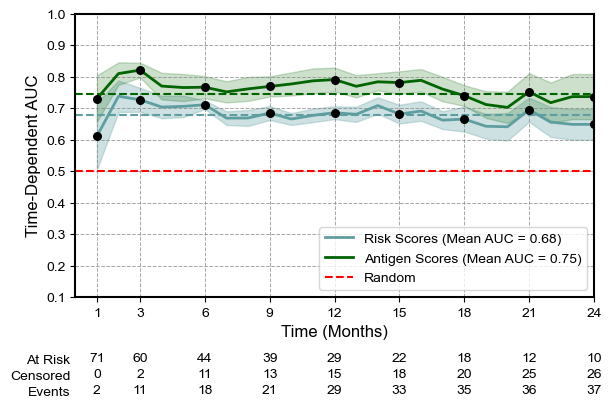

In [117]:
time_points_highlight_train = np.concatenate(([1], np.arange(3, 25, step=3)))
# Risk Scores
se_auc_curve = time_dependent_auc_train.std() / np.sqrt(time_dependent_auc_train.shape[0])
ci_lower =  np.asarray(time_dependent_auc_train.mean() - 1.96 * se_auc_curve, dtype=float)
ci_upper = np.asarray(time_dependent_auc_train.mean() + 1.96 * se_auc_curve, dtype=float)
samples_at_risk_train = calculate_samples_at_risk(y_time_train, time_points_highlight_train)
auc_values_train = time_dependent_auc_train.mean(skipna=True)

fig = plot_time_dependent_auc(auc_values_train, samples_at_risk_train,
                        mean_auc=auc_values_train.mean(),
                        ci_lower=ci_lower, ci_upper=ci_upper,
                        time_points_highlight=time_points_highlight_train,
                        time_measure = "Months", max_time_point = 24,
                        color_auc = "CadetBlue", color_mean="CadetBlue", color_ci="CadetBlue",
                        figures_dir = config.figures_dir, save_fig=False)

# Antigen Scores
se_auc_curve = time_dependent_auc_antigen_train.std() / np.sqrt(time_dependent_auc_antigen_train.shape[0])
ci_lower =  np.asarray(time_dependent_auc_antigen_train.mean() - 1.96 * se_auc_curve, dtype=float)
ci_upper = np.asarray(time_dependent_auc_antigen_train.mean() + 1.96 * se_auc_curve, dtype=float)
auc_antigen_values_train = time_dependent_auc_antigen_train.mean(skipna=True)

ax_auc = fig.get_axes()[0]
ax_auc.plot(auc_antigen_values_train.index, auc_antigen_values_train.values, color="DarkGreen", linestyle='-', linewidth=2)
ax_auc.axhline(y=mean_auc_antigen_train.mean(), color="DarkGreen", linestyle='--', linewidth=1.5)
ax_auc.scatter(time_points_highlight_train, auc_antigen_values_train[time_points_highlight_train], color="black", s=30, zorder=3)
ax_auc.fill_between(time_points, ci_lower, ci_upper, color='DarkGreen', alpha=0.2)
ax_auc.set_ylim(0.1,1.0)
handles = ax_auc.get_lines()
handles=[handles[i] for i in [0, 3, 2]]
ax_auc.legend(handles, [f"Risk Scores (Mean AUC = {auc_values_train.mean():.2f})",
                        f"Antigen Scores (Mean AUC = {mean_auc_antigen_train.mean():.2f})",
                        "Random"], fontsize=10, loc='lower right')
save_path = Path(config.figures_dir) / f'time-dependent_auc_riskScore-antigenScore_trainingSet_folds_{number_peptides}.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')

## Calculated on all predictions

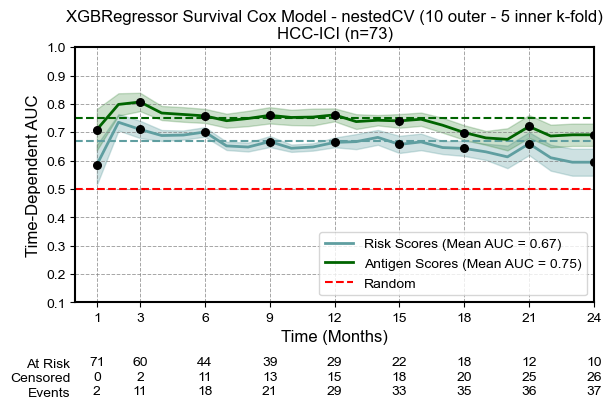

In [118]:
time_points_highlight_train = np.concatenate(([1], np.arange(3, 25, step=3)))
# Risk Scores
se_auc_curve = time_dependent_auc_train_full.std() / np.sqrt(time_dependent_auc_train_full.shape[0])
ci_lower =  np.asarray(time_dependent_auc_train_full.mean() - 1.96 * se_auc_curve, dtype=float)
ci_upper = np.asarray(time_dependent_auc_train_full.mean() + 1.96 * se_auc_curve, dtype=float)
auc_values_train = time_dependent_auc_train_full.mean(skipna=True)

fig = plot_time_dependent_auc(auc_values_train, samples_at_risk_train,
                        mean_auc=mean_auc_train_full.mean(),
                        ci_lower=ci_lower, ci_upper=ci_upper,
                        time_points_highlight=time_points_highlight_train,
                        time_measure = "Months", max_time_point = 24,
                        color_auc = "CadetBlue", color_mean="CadetBlue", color_ci="CadetBlue",
                        figures_dir = config.figures_dir, save_fig=False)

# Antigen Scores
se_auc_curve = time_dependent_auc_antigen_train_full.std() / np.sqrt(time_dependent_auc_antigen_train_full.shape[0])
ci_lower =  np.asarray(time_dependent_auc_antigen_train_full.mean() - 1.96 * se_auc_curve, dtype=float)
ci_upper = np.asarray(time_dependent_auc_antigen_train_full.mean() + 1.96 * se_auc_curve, dtype=float)
auc_antigen_values_train = time_dependent_auc_antigen_train_full.mean(skipna=True)

ax_auc = fig.get_axes()[0]
ax_auc.plot(auc_antigen_values_train.index, auc_antigen_values_train.values, color="DarkGreen", linestyle='-', linewidth=2)
ax_auc.axhline(y=mean_auc_antigen_train_full.mean(), color="DarkGreen", linestyle='--', linewidth=1.5)
ax_auc.scatter(time_points_highlight_train, auc_antigen_values_train[time_points_highlight_train], color="black", s=30, zorder=3)
ax_auc.fill_between(time_points, ci_lower, ci_upper, color='DarkGreen', alpha=0.2)
ax_auc.set_ylim(0.1,1.0)
handles = ax_auc.get_lines()
handles=[handles[i] for i in [0, 3, 2]]
ax_auc.set_title("XGBRegressor Survival Cox Model - nestedCV (10 outer - 5 inner k-fold)\nHCC-ICI (n=73)", fontsize=12)
ax_auc.legend(handles, [f"Risk Scores (Mean AUC = {mean_auc_train_full.mean():.2f})",
                        f"Antigen Scores (Mean AUC = {mean_auc_antigen_train_full.mean():.2f})",
                        "Random"], fontsize=10, loc='lower right')
save_path = Path(config.figures_dir) / f'time-dependent_auc_riskScore-antigenScore_trainingSet_allData_{number_peptides}.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')

 # Calculate Antigen Scores

In [119]:
antigen_scores_time_event_train = calculate_antigen_scores_scaled(train_shap_values, y_time_train.abs(), y_event_train, top_peptides_train, scaler=None, scaler_antigens=None, return_all = False)
antigen_scores_time_event_train.to_csv("/home/creyna/Vogl-lab_Projects_git/HCC/antigen_scores_test.csv", index=False)

 ## Get threshold for Antigen Scores

In [120]:
%%R -o threshold
library("maxstat")
library("survival")

df <- read.csv("/home/creyna/Vogl-lab_Projects_git/HCC/antigen_scores_test.csv")
# Create a survival object
surv_obj <- Surv(df$OS.months, df$OS.Status)
# Run the maxstat test to find the optimal cutpoint for antigen_score
result <- maxstat.test(surv_obj ~ `Antigen.Score..Scaled.`, data = df,
                       smethod = "LogRank",   # using log-rank test statistic
                       pmethod = "condMC",    # conditional Monte Carlo p-value estimation
                       B = 9999)
# Save the estimate result to a new variable
threshold <- round(result$estimate,7)

In [121]:
antigen_scores_time_event_train, antigen_threshold_train, shap_scaler_train, antigen_scaler_train = calculate_antigen_scores_scaled(train_shap_values, y_time_train.abs(), y_event_train, top_peptides_train, scaler=None, scaler_antigens=None, threshold=threshold[0], return_all = True)
antigen_scores_time_event_train.to_csv("/home/creyna/Vogl-lab_Projects_git/HCC/antigen_scores_test.csv", index=False)

with open("antigen_threshold_train.pkl", "wb") as f:
    pickle.dump(antigen_threshold_train, f)
# Save shap_scaler_train
with open("shap_scaler_train.pkl", "wb") as f:
    pickle.dump(shap_scaler_train, f)
# Save antigen_scaler_train
with open("antigen_scaler_train.pkl", "wb") as f:
    pickle.dump(antigen_scaler_train, f)

INFO:survival_helpers:Figure saved to /home/creyna/Vogl-lab_Projects_git/HCC/Data/Predictions/Figures/figures_censored-deceased/kaplan_meier_xgb_Cox-Hazard_trainingSet_8011.png
INFO:survival_helpers:Log-Rank Test p-value: 0.0004


0.00036676545961483286

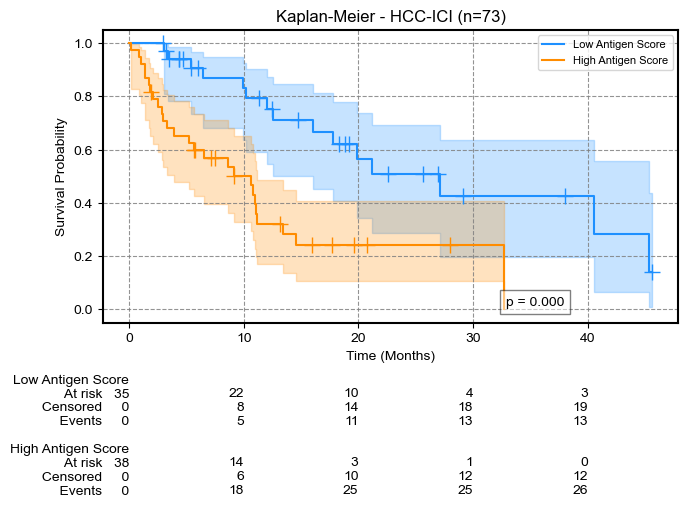

In [122]:
# Assuming the antigen score has been dichotomized into "Antigen Score (Dichotomized)" and you have time and event data in a data frame
labels = {0: 'Low Antigen Score', 1: 'High Antigen Score'}

# Plot for Training Set
plot_kaplan_meier(antigen_scores_time_event_train, 'OS months', 'OS Status', 'Antigen Score (Dichotomized)', labels,
                  title="Kaplan-Meier - HCC-ICI (n=73)",
                  xlabel="Time (Months)", ylabel="Survival Probability",
                  save_fig=True, figures_dir=config.figures_dir, suffix_file=f'xgb_Cox-Hazard_trainingSet_{number_peptides}')
# Perform log-rank test for Training Set
perform_logrank_test(antigen_scores_time_event_train, 'OS months', 'OS Status', 'Antigen Score (Dichotomized)')

## Format metadata

In [123]:
top_peptides_df = feature_manager.get_data_with_target()[top_peptides_train].droplevel(0)
clinical_meta = metadata_handler.get_individuals_metadata_df()
clinical_meta = pd.concat([clinical_meta,
                         pd.concat([antigen_scores_time_event_train.iloc[:,2:], risk_scores_train.mean(axis=1).to_frame().rename(columns={0: "Risk Score"})], axis=1, names=["SampleName"]), top_peptides_df],  axis = 1)
# Replace 1 with the name of the peptide and 0 with "absence"
for peptide_column in top_peptides_train:
    clinical_meta[peptide_column] = clinical_meta[peptide_column].apply(
        lambda x: 'presence' if x == 1 else 'absence'
    )
clinical_meta['Sex_ctg'] = clinical_meta['Sex'].apply(lambda x: "Male" if x == 1 else "Female")

clinical_meta['Age_ctg'] = clinical_meta['Age'].apply(lambda x: ">=65" if x >=65 else "<65")

clinical_meta['AFP 100_ctg'] = clinical_meta['AFP'].apply(lambda x: ">=100" if x >=100 else "<100")
clinical_meta['AFP 400_ctg'] = clinical_meta['AFP'].apply(lambda x: ">=400" if x >=400 else "<400")

clinical_meta["Line_of_syst.treatment"] = pd.get_dummies(clinical_meta["Line_of_syst.treatment_ctg"], drop_first=True, dtype=int)

clinical_meta["BMI Category"] = clinical_meta["BMI"].apply(lambda x: "<18.5" if x < 18.5 else
                                                        ">=18.5<25" if 18.5 <= x < 25 else
                                                        ">=25<30" if 25 <= x < 30 else
                                                        ">=30<35" if 30 <= x < 35 else
                                                        ">=35")
clinical_meta = pd.concat([clinical_meta, pd.get_dummies(clinical_meta["BMI Category"], drop_first=False, dtype=int).drop(columns=[">=18.5<25"])], axis =1)

clinical_meta['Cirrhosis_ctg'] = clinical_meta['Cirrhosis_ctg'].apply(lambda x: "cirrhosis" if x == "yes" else "no cirrhosis")
clinical_meta['Cirrhosis_ctg'] = pd.Categorical(clinical_meta['Cirrhosis_ctg'],
                                                     categories=["no cirrhosis","cirrhosis"], ordered=True)

clinical_meta = pd.concat([clinical_meta, pd.get_dummies(clinical_meta["Child-Pugh stage_ctg"], drop_first=True, dtype=int).rename(columns={"stage B": "Child-Pugh stage B"})], axis=1)
clinical_meta['MVI_ctg'] = clinical_meta['MVI_ctg'].apply(lambda x: "MVI" if x == "yes" else "no MVI")
clinical_meta['MVI_ctg'] = pd.Categorical(clinical_meta['MVI_ctg'],
                                                     categories=["no MVI","MVI"], ordered=True)
clinical_meta['EHS_ctg'] = clinical_meta['EHS_ctg'].apply(lambda x: "EHS" if x == "yes" else "no EHS")
clinical_meta['EHS_ctg'] = pd.Categorical(clinical_meta['EHS_ctg'],
                                                     categories=["no EHS","EHS"], ordered=True)

# Merge "stage A" and "stage B" into "stage AB"
clinical_meta['BCLC stage_ctg'] = clinical_meta['BCLC stage_ctg'].replace({'stage A': 'stage AB', 'stage B': 'stage AB'})
clinical_meta['BCLC stage_ctg'] = pd.Categorical(clinical_meta['BCLC stage_ctg'],
                                                     categories=["stage AB", "stage C"], ordered=True)
clinical_meta = pd.concat([clinical_meta, pd.get_dummies(clinical_meta["BCLC stage_ctg"], drop_first=True, dtype=int).rename(columns={"stage C": "BCLC stage C"})], axis=1)

clinical_meta['Antigen Score (Dichotomized) ctg'] = clinical_meta['Antigen Score (Dichotomized)'].apply(lambda x: "Low Antigen Score" if x == 0 else "High Antigen Score")
clinical_meta['Antigen Score (Dichotomized) ctg'] = pd.Categorical(clinical_meta['Antigen Score (Dichotomized) ctg'],
                                                     categories=["Low Antigen Score", "High Antigen Score"], ordered=True)

clinical_meta = pd.concat([clinical_meta, pd.get_dummies(clinical_meta["mRECIST_ctg"], drop_first=True, dtype=int)], axis = 1)

## univariate analysis

In [124]:
# Define your list of variables (including any top peptides if needed)
variables = [
    "Sex_ctg", "Age_ctg", "ORR_ctg", "DCR_ctg", "Line_of_syst.treatment_ctg",
    "Cirrhosis_ctg", "Child-Pugh stage_ctg", "ECOG_ctg", "MVI_ctg", "EHS_ctg", "BCLC stage_ctg",
    "AFP 100_ctg", "AFP 400_ctg", "Antigen Score (Dichotomized) ctg",
    *list(top_peptides_train)  # assuming top_peptides_train is defined
]

# Run the univariate analysis function
univariate_results, univariate_kmf  = run_univariate_km_analysis(clinical_meta, variables, config.figures_dir, f"{number_peptides}")

# Now univariate_results is a DataFrame summarizing the key findings.
#print(univariate_results)
print(tabulate(univariate_kmf, headers='keys', tablefmt='latex', showindex=False))
significant_predictors_kmf = univariate_results[univariate_results["P-value"] < 0.1]["Variable"].unique().tolist()
significant_predictors_kmf

\begin{tabular}{llrrrrl}
\hline
 Variable                  & Group             &   Size &   Median OS (Months) &   95\% CI Lower &   95\% CI Upper & P-value         \\
\hline
 Sex                       & Female            &     18 &                10.78 &           6.41 &         inf    &                 \\
                           & Male              &     55 &                14.6  &          10.22 &          27.09 & 0.8951          \\
 Age                       & \ensuremath{<}65               &     23 &                11.11 &           8.58 &          45.36 &                 \\
                           & \ensuremath{>}=65              &     50 &                14.6  &           9.96 &          27.09 & 0.8594          \\
 \textbackslash{}textbf\{ORR\}              & ORR               &     23 &                27.09 &          11.11 &          45.36 &                 \\
                           & non ORR           &     50 &                10.98 &           5.36 &          16.04

['ORR',
 'DCR',
 'Child-Pugh stage',
 'MVI',
 'AFP 100',
 'AFP 400',
 'Antigen Score',
 'agilent_26654',
 'twist_63959',
 'twist_58791',
 'twist_28586',
 'agilent_241214',
 'agilent_198784',
 'agilent_225378',
 'agilent_73606',
 'agilent_73623',
 'agilent_7108',
 'agilent_225587',
 'twist_47864']

In [125]:
predictors_cont = ["Age", "AFP", "Antigen Score (Scaled)"]

# predictors for categorical variables:
predictors_ctg = {
    "Sex_ctg": "Female",
    "Age_ctg": "<65",
    "ORR_ctg": "ORR",
    "DCR_ctg": "DCR",
    "Line_of_syst.treatment_ctg": "first",
    "Cirrhosis_ctg": "no cirrhosis",
    "Child-Pugh stage_ctg": "A",
    "ECOG_ctg": "no symptoms",
    "MVI_ctg": "no MVI",
    "EHS_ctg": "no EHS",
    "BCLC stage_ctg": "AB",
    "AFP 100_ctg": "<100",
    "AFP 400_ctg": "<400",
    "Antigen Score (Dichotomized) ctg": "Low"
}
predictors_ctg.update({variable: "absence" for variable in list(top_peptides_train)})

# Run the univariate analysis:
univariate_results, univariate_cph = run_univariate_cox_analysis(clinical_meta, predictors_cont, predictors_ctg)
significant_predictors_cph = univariate_results[univariate_results["P-value"] < 0.1]["Variable"].tolist()
print(tabulate(univariate_cph, headers='keys', tablefmt='latex', showindex=False))
significant_predictors_cph

\begin{tabular}{llrrrl}
\hline
 Variable                  & Group                            &   Hazard Ratio &   95\% CI Lower &   95\% CI Upper & P-value         \\
\hline
 Age                       &                                  &           1    &           0.96 &           1.03 & 0.7783          \\
 \textbackslash{}textbf\{AFP\}              &                                  &           1    &           1    &           1    & \textbackslash{}textbf\{0.0112\} \\
 \textbackslash{}textbf\{Antigen Score\}    &                                  &           5.92 &           1.45 &          24.25 & \textbackslash{}textbf\{0.0134\} \\
 Sex                       & Male - Ref Female                &           1.05 &           0.51 &           2.15 & 0.8954          \\
                           & \ensuremath{>}=65 - Ref \ensuremath{<}65                   &           0.94 &           0.49 &           1.83 & 0.8597          \\
 \textbackslash{}textbf\{ORR\}              & \textbackslash{}

['AFP',
 'Antigen Score',
 'ORR',
 'DCR',
 'Child-Pugh stage',
 'MVI',
 'AFP 100',
 'AFP 400',
 'Antigen Score',
 'agilent_26654',
 'twist_63959',
 'twist_58791',
 'twist_28586',
 'agilent_241214',
 'agilent_198784',
 'agilent_225378',
 'agilent_73606',
 'agilent_73623',
 'agilent_7108',
 'agilent_225587',
 'twist_47864']

## Multivariate

In [126]:
# Function to extract the first and second parts
def extract_parts(text):
    pattern = r'C\(`([^`]+)`\)\[T\.([^\]]+)\]'
    match = re.match(pattern, text)
    if match:
        return match.groups()  # returns a tuple (first_part, second_part)
    else:
        return text, ''  # If it doesn't match the pattern, return the original text and an empty string

references_dict = {"Sex":"Female", "Age":"<65", "ORR":"ORR", "DCR":"DCR",
                 "Line_of_syst.treatment":"first", "Cirrhosis":"no cirrhosis",
                 "Child-Pugh stage":"A", "ECOG":"no symptoms" , "MVI":"no MVI", "EHS":"no EHS",
                 "BCLC stage":"AB", "AFP 100":"<100", "AFP 400":"<400",
                  "Antigen Score": "Low"}
references_dict.update({variable: "absence" for variable in list(top_peptides_train)})

# Step 1: Perform univariate analysis to select initial candidate variables

significant_predictors = ['Child-Pugh stage', 'MVI', 'AFP 400', 'Antigen Score']
significant_predictors = [key for key in predictors_ctg if any(value in key for value in significant_predictors)] #+ ['Antigen Score (Scaled)']
continuous_predictors = ['Sex', 'AFP', 'Antigen Score (Scaled)']

# Step 2: Fit Cox model with all candidate variables
cph = CoxPHFitter()
formula = " + ".join([f"C(`{p}`)" if p not in continuous_predictors else f"`{p}`" for p in significant_predictors])
cph.fit(clinical_meta[["OS months", "OS Status"] + significant_predictors],
        duration_col="OS months", event_col="OS Status", formula=formula)


# Step 3: Start the backward selection process
selected_predictors = significant_predictors.copy()
best_aic = cph.AIC_partial_

# Conditional Backward Selection Loop
while len(selected_predictors) > 0:
    aic_with_candidates = []
    # Loop through each predictor and remove it, refit the model, and calculate AIC
    for predictor in selected_predictors:
        predictors_to_fit = [p for p in selected_predictors if p != predictor]

        cph = CoxPHFitter()

        formula = " + ".join([f"C(`{p}`)" if p not in continuous_predictors else f"`{p}`" for p in predictors_to_fit])
        #formula = " + ".join([f"C(`{p}`)" for p in predictors_to_fit])
        cph.fit(clinical_meta[["OS months", "OS Status"] + predictors_to_fit],
                duration_col="OS months", event_col="OS Status", formula=formula)

        # Store the AIC for this candidate model
        aic_with_candidates.append((cph.AIC_partial_, predictor))

    # Sort by AIC and select the model with the smallest AIC
    aic_with_candidates.sort()
    best_new_aic, best_candidate_to_remove = aic_with_candidates[0]

    # If the best model with one less predictor has a better AIC, remove the variable
    if best_new_aic < best_aic:
        best_aic = best_new_aic
        selected_predictors.remove(best_candidate_to_remove)
        print(f"Removed {best_candidate_to_remove}, AIC: {best_aic}")
    else:
        break  # Stop if no improvement

# Final Model with selected predictors
#selected_predictors = selected_predictors + ['Antigen Score (Dichotomized) ctg']
print("Final Model Predictors:", selected_predictors)

# Fit the final Cox model with the selected predictors
cph_bwd = CoxPHFitter()
#formula = " + ".join([f"C(`{p}`)" for p in selected_predictors])
formula = " + ".join([f"C(`{p}`)" if p not in continuous_predictors else f"`{p}`" for p in selected_predictors])
cph_bwd.fit(clinical_meta[["OS months", "OS Status"] + selected_predictors],
        duration_col="OS months", event_col="OS Status", formula=formula)
# Print the final model summary
cph_bwd.print_summary()


multivariate_results = []
summary = cph_bwd.summary
# Loop over the categories in the summary and create readable names
for idx in summary.index:
    # Extract HR, 95% CI (lower, upper), and p-value for each category
    hr = summary.loc[idx, 'exp(coef)']  # Hazard Ratio
    ll = summary.loc[idx, 'exp(coef) lower 95%']  # Lower bound of 95% CI
    ul = summary.loc[idx, 'exp(coef) upper 95%']  # Upper bound of 95% CI
    coef = summary.loc[idx, 'coef']
    score_points = math.ceil(coef * 2 * 10)/10.0
    p_value = summary.loc[idx, 'p']

    variable, category = extract_parts(idx)

    # Extract the readable category name
    clean_predictor = clean_predictor_name(variable)
    if category != '' :
        category_name = extract_category_name(category)+ f" - Ref {references_dict[clean_predictor]}"
    else:
        category_name = ''
    multivariate_results.append((clean_predictor, category_name, hr, ll, ul, coef, score_points, p_value))

# Convert results to a DataFrame for better readability
multivariate_bwd_cph = pd.DataFrame(multivariate_results, columns=["Variable", "Group", "Hazard Ratio", "95% CI Lower", "95% CI Upper", "Coef", "Score points","P-value"])
multivariate_bwd_cph['Hazard Ratio'] = multivariate_bwd_cph['Hazard Ratio'].round(2)
multivariate_bwd_cph['95% CI Lower'] = multivariate_bwd_cph['95% CI Lower'].round(2)
multivariate_bwd_cph['95% CI Upper'] = multivariate_bwd_cph['95% CI Upper'].round(2)
multivariate_bwd_cph['Coef'] = multivariate_bwd_cph['Coef'].round(2)
multivariate_bwd_cph['P-value'] = multivariate_bwd_cph['P-value'].round(4)

print(tabulate(multivariate_bwd_cph, headers='keys', tablefmt='latex', showindex=False))

Removed MVI_ctg, AIC: 253.16711068254023
Final Model Predictors: ['Child-Pugh stage_ctg', 'AFP 400_ctg', 'Antigen Score (Dichotomized) ctg']


<lifelines.CoxPHFitter: fitted with 73 total observations, 32 right-censored observations>
             duration col = 'OS months'
                event col = 'OS Status'
      baseline estimation = breslow
   number of observations = 73
number of events observed = 41
   partial log-likelihood = -123.58
         time fit was run = 2025-04-08 12:31:11 UTC

---
                                                             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                                                    
C(`Child-Pugh stage_ctg`)[T.stage B]                         1.55      4.72      0.36            0.85            2.25                2.34                9.52
C(`AFP 400_ctg`)[T.>=400]                                    1.03      2.81      0.36            0.33            1.73                1.39                5.67
C(`Antigen Score (Dichotomized) ctg`)[T.High Antigen Score]  1.14      3.12      0.38            0.40            1.88                1.49                6.54

                                                             cmp to    z      p  -log2(p)
covariate                                                                                
C(`Child-Pugh stage_ctg`)[T.stage B]                           0.00 4.33 <0.005     16.06
C(`AFP 400_ctg`)[T.>=400]                                      0.00 2.89 <0.005      8.00
C(`Antigen Score (Dichotomized) ctg`)[T.High Antigen Score]    0.00 3.02 <0.005      8.61
---
Concordance = 0.79
Partial AIC = 253.17
log-likelihood ratio test = 39.80 on 3 df
-log2(p) of ll-ratio test = 26.34

\begin{tabular}{llrrrrrr}
\hline
 Variable         & Group            &   Hazard Ratio &   95\% CI Lower &   95\% CI Upper &   Coef &   Score points &   P-value \\
\hline
 Child-Pugh stage & B - Ref A        &           4.72 &           2.34 &           9.52 &   1.55 &            3.2 &    0      \\
 AFP 400          & \ensuremath{>}=400 - Ref \ensuremath{<}400 &           2.81 &           1.39 &           5.67 &   1.03 &            2.1 &    0.0039 \\
 Antigen Score    & High - Ref Low   &           3.12 &           1.49 &           6.54 &   1.14 &            2.3 &    0.0026 \\
\hline
\end{tabular}


In [127]:
clinical_meta_test = pd.read_excel('/home/creyna/Vogl-lab_Projects_git/HCC/Metadata/HCC_TKI_metadata_with_scores.xlsx')
y_time_test = clinical_meta_test["OS months"]
y_event_test = clinical_meta_test["OS Status"]
y_time_test = pd.Series(np.where(y_event_test == 1, y_time_test, -y_time_test),
                        index=clinical_meta_test.index)

validation_data = clinical_meta_test[selected_predictors]
predicted_risk_scores_bwd = cph_bwd.predict_partial_hazard(validation_data)

# Calculate the C-index on the external validation set
c_index_external = c_index_scorer_ipcw(y_time_train, y_time_test, predicted_risk_scores_bwd.values)
print(f"C-index on the testing validation set: {c_index_external:.4f}")

C-index on the testing validation set: 0.5540


 ## Forest plot

In [128]:
def remove_ctg_name(label):
    # Remove '_ctg' or similar parts
    label = label.replace('_ctg', '')
    label = label.replace('Category', '')
    label = label.replace('(Scaled)', '')
    #label = label.replace('stage', '')
    # Remove '(Dichotomized) ctg'
    label = re.sub(r'\(Dichotomized\) ctg', '', label)
    # Optionally, remove any trailing spaces
    return label.strip()

def remove_stage_name(label):
    # Remove '_ctg' or similar parts
    label = label.replace('_ctg', '')
    label = label.replace('Category', '')
    label = label.replace('(Scaled)', '')
    label = label.replace('stage', '')
    # Remove '(Dichotomized) ctg'
    label = re.sub(r'Antigen Score', '', label)
    # Optionally, remove any trailing spaces
    return label.strip()
# Example list with the desired order of variables
variable_order = multivariate_bwd_cph['Variable'].unique()
# Iterate over unique variable names in the 'Variable' column
new_rows = []
for variable in variable_order:
    # Create the new row with the reference values from the dictionary
    new_row = {
        'Variable': variable,  # Variable name
        'Group': references_dict.get(variable, ''),  # Group from ref_dict, default to empty string if not found
        'Hazard Ratio': 1,  # Set Hazard Ratio to 1
        '95% CI Lower': None,  # Empty string for 95% CI Lower
        '95% CI Upper': None,  # Empty string for 95% CI Upper
        'Coef': None,  # Empty string for Coef
        'Score points': None,  # Empty string for Score points
        'P-value': None  # Empty string for P-value
    }
    new_rows.append(new_row)
# Append the new rows to the original DataFrame
multivariate_forest = pd.concat([multivariate_bwd_cph, pd.DataFrame(new_rows)], ignore_index=True)
multivariate_forest['Group'] = multivariate_forest['Group'].str.replace(r'\s*- Ref.*', '', regex=True)
multivariate_forest['Variable'] = pd.Categorical(multivariate_forest['Variable'], categories=variable_order, ordered=True)
multivariate_forest = multivariate_forest.sort_values(by=['Variable', 'Hazard Ratio'], ascending=[True, True]).reset_index(drop=True)
#check if order is correct for reference before continuing
multivariate_forest

/tmp/ipykernel_537598/4233913953.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  multivariate_forest = pd.concat([multivariate_bwd_cph, pd.DataFrame(new_rows)], ignore_index=True)


,Variable,Group,Hazard Ratio,95% CI Lower,95% CI Upper,Coef,Score points,P-value
0,Child-Pugh stage,A,1.00,NaN,NaN,NaN,NaN,NaN
1,Child-Pugh stage,B,4.72,2.34,9.52,1.55,3.2,0.0000
2,AFP 400,<400,1.00,NaN,NaN,NaN,NaN,NaN
3,AFP 400,>=400,2.81,1.39,5.67,1.03,2.1,0.0039
4,Antigen Score,Low,1.00,NaN,NaN,NaN,NaN,NaN
5,Antigen Score,High,3.12,1.49,6.54,1.14,2.3,0.0026


In [129]:
unique_variables = ['Child-Pugh stage_ctg', 'AFP 400_ctg', 'Antigen Score (Dichotomized) ctg']  # Add your actual list here

# Initialize an empty list to hold row dictionaries
rows = []

for variable in unique_variables:
    # If you need special treatment for a specific variable (e.g., "Antigen Score (Scaled)")
    # adjust the condition as needed. Here, we check for "Antigen Score (Scaled)".
    if variable == "Antigen Score (Scaled)":
        # Add a single row with a fixed value (here, size=73)
        rows.append({
            'Variable': variable,
            'Group': '',
            'N': 73
        })
    else:
        # For other variables, count the unique values using value_counts
        counts = clinical_meta[variable].value_counts()
        # Create one row per group
        for group, size in counts.items():
            rows.append({
                'Variable': variable,
                'Group': group,
                'N': size
            })
# Convert the list of dictionaries into a DataFrame
counts = pd.DataFrame(rows)
counts['Variable'] = counts['Variable'].apply(remove_ctg_name)
counts['Group'] = counts['Group'].apply(remove_stage_name)
multivariate_forest = multivariate_forest.merge(counts, on = ["Variable", "Group"], how="inner")
multivariate_forest

,Variable,Group,Hazard Ratio,95% CI Lower,95% CI Upper,Coef,Score points,P-value,N
0,Child-Pugh stage,A,1.00,NaN,NaN,NaN,NaN,NaN,44
1,Child-Pugh stage,B,4.72,2.34,9.52,1.55,3.2,0.0000,29
2,AFP 400,<400,1.00,NaN,NaN,NaN,NaN,NaN,51
3,AFP 400,>=400,2.81,1.39,5.67,1.03,2.1,0.0039,22
4,Antigen Score,Low,1.00,NaN,NaN,NaN,NaN,NaN,35
5,Antigen Score,High,3.12,1.49,6.54,1.14,2.3,0.0026,38


In [130]:
multivariate_forest.loc[multivariate_forest['Variable'] == "AFP 400", "Variable"] = "AFP"
multivariate_forest['Variable'] = multivariate_forest['Variable'].astype('category').cat.add_categories("")
multivariate_forest.loc[multivariate_forest['Variable'].duplicated(), 'Variable'] = ""
multivariate_forest_reversed = multivariate_forest[::-1].copy()
multivariate_forest_reversed['log_HR'] = np.log(multivariate_forest_reversed['Hazard Ratio'])
multivariate_forest_reversed['log_95% CI Lower'] = np.log(multivariate_forest_reversed['95% CI Lower'])
multivariate_forest_reversed['log_95% CI Upper'] = np.log(multivariate_forest_reversed['95% CI Upper'])
multivariate_forest_reversed

,Variable,Group,Hazard Ratio,95% CI Lower,95% CI Upper,Coef,Score points,P-value,N,log_HR,log_95% CI Lower,log_95% CI Upper
5,,High,3.12,1.49,6.54,1.14,2.3,0.0026,38,1.137833,0.398776,1.877937
4,Antigen Score,Low,1.00,NaN,NaN,NaN,NaN,NaN,35,0.000000,NaN,NaN
3,,>=400,2.81,1.39,5.67,1.03,2.1,0.0039,22,1.033184,0.329304,1.735189
2,AFP,<400,1.00,NaN,NaN,NaN,NaN,NaN,51,0.000000,NaN,NaN
1,,B,4.72,2.34,9.52,1.55,3.2,0.0000,29,1.551809,0.850151,2.253395
0,Child-Pugh stage,A,1.00,NaN,NaN,NaN,NaN,NaN,44,0.000000,NaN,NaN


0

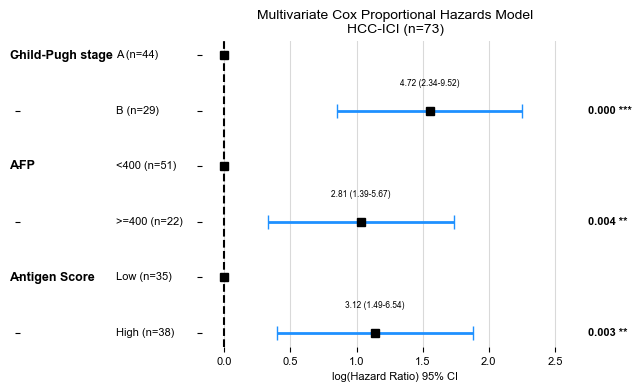

In [131]:
forestplot_survival(multivariate_forest_reversed,
           save_path=config.figures_dir,
           suffix_file=f'coxph_antigenScore',
           save_fig = True,
           title="Multivariate Cox Proportional Hazards Model\nHCC-ICI (n=73)")

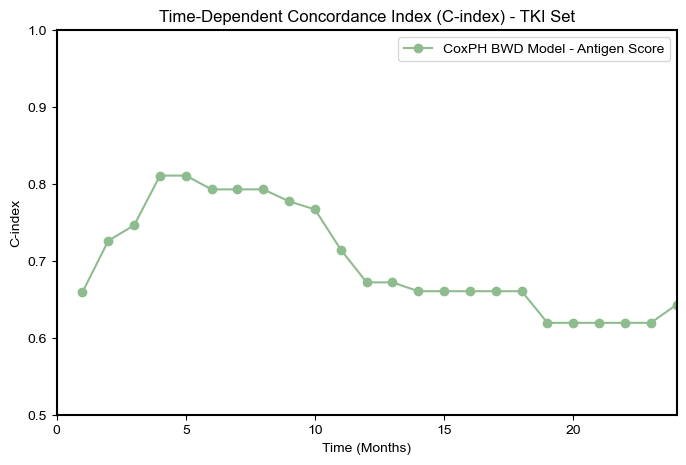

In [132]:
# Define time horizons (percentiles of observed survival times in external validaion set)
time_horizons = np.arange(1,25,1)

# Compute time-dependent C-index using inverse probability of censoring weights (IPCW)
c_indices = []
for t in time_horizons:

    # Compute C-index for this time point
    c_index_t = c_index_scorer_ipcw(
        y_time_train,
        y_time_test,
        predicted_risk_scores_bwd,
        tau=t
    )

    c_indices.append(c_index_t)

# Plot the time-dependent C-index
plt.figure(figsize=(8, 5))
plt.plot(time_horizons, c_indices, color = 'darkseagreen', marker='o', linestyle='-', label="CoxPH BWD Model - Antigen Score")
plt.xlabel("Time (Months)")
plt.ylabel("C-index")
plt.title("Time-Dependent Concordance Index (C-index) - TKI Set")
plt.legend(loc="upper right")  # Legend positioned at the top right
plt.ylim(0.5, 1.0)
plt.xlim(0, 24)
fig_path = Path(config.figures_dir) / f'Time-Dependent_C-index_testingSet_{number_peptides}.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')

## Responders vs Antigen Scores

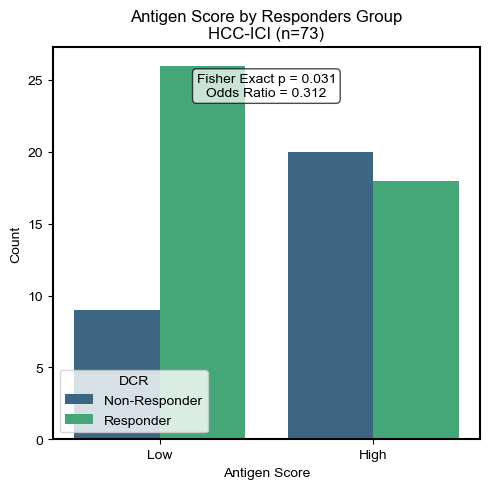

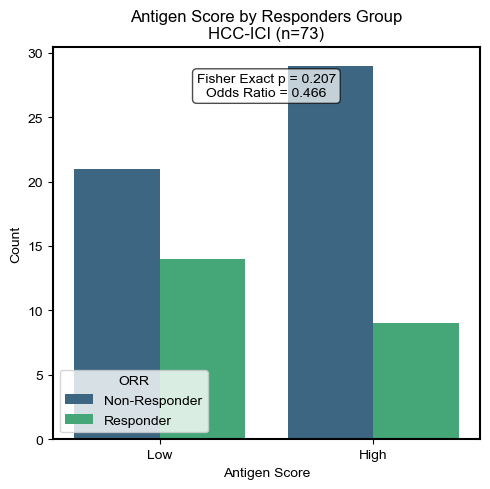

In [133]:
mapping = {0.0: 'Non-Responder', 1.0: 'Responder'}
mapping_antigen = {0: 'Low', 1: 'High'}

# Call the function
fig = barplot_counts_fisher_test(
    df=clinical_meta,
    cat_var1='DCR',
    title="Antigen Score by Responders Group\nHCC-ICI (n=73)",
    cat_var2='Antigen Score (Dichotomized)',
    legend_title='DCR',
    y_label='Count',
    x_label='Antigen Score',
    mapping1=mapping,
    mapping2=mapping_antigen,
    figsize=(5, 5),
    palette='viridis',
    save_path=config.figures_dir,
    suffix_file=f"antigenScore_DCR_{number_peptides}"
)
# Call the function
fig = barplot_counts_fisher_test(
    df=clinical_meta,
    title="Antigen Score by Responders Group\nHCC-ICI (n=73)",
    cat_var1='ORR',
    cat_var2='Antigen Score (Dichotomized)',
    legend_title='ORR',
    y_label='Count',
    x_label='Antigen Score',
    mapping1=mapping,
    mapping2=mapping_antigen,
    figsize=(5, 5),
    palette='viridis',
    save_path=config.figures_dir,
    suffix_file=f"antigenScore_ORR_{number_peptides}"
)

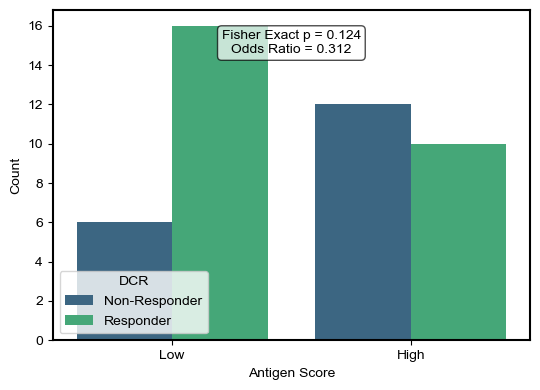

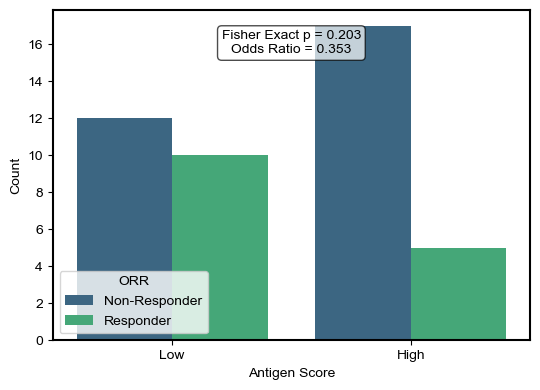

In [134]:
child_pugh_A_df = clinical_meta[clinical_meta['Child-Pugh stage'] == 1]
# Call the function1
fig = barplot_counts_fisher_test(
    df=child_pugh_A_df,
    cat_var1='DCR',
    cat_var2='Antigen Score (Dichotomized)',
    legend_title='DCR',
    y_label='Count',
    x_label='Antigen Score',
    mapping1=mapping,
    mapping2=mapping_antigen,
    figsize=(5.5, 4),
    palette='viridis',
    save_path=config.figures_dir,
    suffix_file=f"childPughA_antigenScore_DCR_{number_peptides}"
)

# Call the function
fig = barplot_counts_fisher_test(
    df=child_pugh_A_df,
    cat_var1='ORR',
    cat_var2='Antigen Score (Dichotomized)',
    legend_title='ORR',
    y_label='Count',
    x_label='Antigen Score',
    mapping1=mapping,
    mapping2=mapping_antigen,
    figsize=(5.5, 4),
    palette='viridis',
    save_path=config.figures_dir,
    suffix_file=f"childPughA_antigenScore_ORR_{number_peptides}"
)

Mann–Whitney Test statistic: 804.0, p-value: 0.062
Mann–Whitney Test statistic: 677.0, p-value: 0.228


/home/creyna/miniconda3/envs/ML_env/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/creyna/miniconda3/envs/ML_env/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/creyna/miniconda3/envs/ML_env/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/creyna/miniconda3/envs/ML_env/lib/python3.10/site-packages/seaborn/_oldcore.py:1119

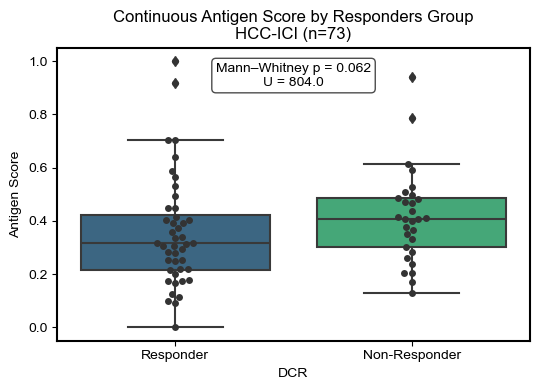

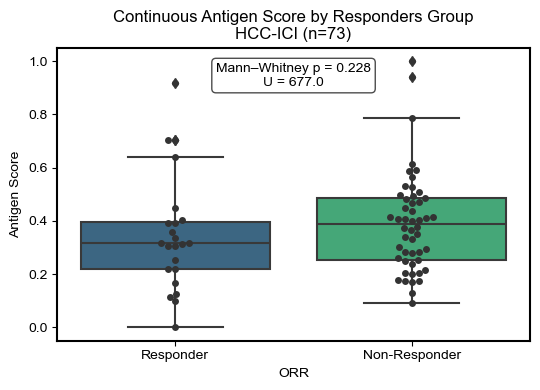

In [135]:
mapping = {0.0: 'Non-Responder', 1.0: 'Responder'}
mapping_antigen = {0: 'Low', 1: 'High'}
fig = boxplot_compare_distribution_by_category(clinical_meta,
                                               cont_var='Antigen Score (Scaled)',
                                               title="Continuous Antigen Score by Responders Group\nHCC-ICI (n=73)",
                                               cat_var='DCR',
                                               cat_mapping=mapping,
                                               x_label="DCR",
                                               y_label="Antigen Score",
                                               #title="Antigen Score by DCR Group",
                                               figsize=(5.5,4),
                                               # save_path=config.figures_dir,
                                               # suffix_file=f"antigenScore_DCR_{number_peptides}"
                                               )

fig = boxplot_compare_distribution_by_category(clinical_meta,
                                               cont_var='Antigen Score (Scaled)',
                                               cat_var='ORR',
                                               title="Continuous Antigen Score by Responders Group\nHCC-ICI (n=73)",
                                               cat_mapping=mapping,
                                               x_label="ORR",
                                               y_label="Antigen Score",
                                               #title="Antigen Score by DCR Group",
                                               figsize=(5.5,4),
                                               #save_path=config.figures_dir,
                                               #suffix_file=f"antigenScore_ORR_{number_peptides}"
                                               )